# Retail Sarthi Agent powered by Sarvam-M model

In this notebook we will be implementing an agent architecture for a platform that helps kirana shops and small scale businesses get suggestions on inventory management to prevent "Inventory Overhang".This is a part of our final year project as team 46 from CMR University

Our goals : 
- To create a smart agent that understand user query from audio or text format. (ASR and Model)
- Use Agentic RAG so that the agent uses relavent information on its own.
- Call relavent tools for demand forecasting, trends prediction, Inventory Check from DB. 
- Provide simple to understand output to the user. 

In [2]:
# Load model and API Keys
import os 
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

load_dotenv()

tool_llm = ChatOllama(model="llama3.2:latest", temperature=0.9) # Using llama 3.2 as a tool calling router 

SARVAM_API_KEY = os.getenv("Sarvam-API")

#Using Sarvam M for conversation as it has native support of indic Languages 
Convo_llm = ChatOpenAI(model ="sarvam-m",
                 api_key=SARVAM_API_KEY,
                 base_url="https://api.sarvam.ai/v1",
                 ##model_kwargs={"reasoning_effort": "medium"}
                 )




# Structure

So Sarvam's M model does not support tool calling but Llama 3.2 does which is a 3B SLM model with built in tool calling. The idea here is to use Sarvam as the main covnversational Agent while Llama acts as the smart tool calling agent that checks the request and shares it with Llama node which sends that information back to the converation node (Sarvam-M)

In [ ]:
from pydantic import BaseModel, field_validator, ValidationError
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage,AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated,Literal

SUPPORTED_LANG = ["English","Hindi","Kannada","Telugu","Tamil","unknown"]

#Graph State 
class agent_state(MessagesState):
    language : str 


#Conversation Agent Node
def conversation_agent(state:agent_state):
    raw_language = str(state["language"]).strip()
    current_language = raw_language.lower()  # works for Telugu / telugu / TELUGU

    supported_lang = {lang.lower() for lang in SUPPORTED_LANG}
    if current_language not in supported_lang:
        raise ValueError(
            f"Unsupported language: {raw_language}. "
            f"Supported languages are: {sorted(SUPPORTED_LANG)}"
        )

    convo_sys_prompt = f'''
    You are Retail Saarthi, a knowledgeable and friendly digital assistant for Indian Kirana store owners.

    Your Task: > 
    1. Respond to the user's query regarding their business, inventory, or sales.
    2. Use the language specified: {current_language}.

    Language Guidelines:

    [STRICT] If the language is 'unknown' or not clearly mentioned, politely ask the user a question to know which langauge they wish to communicate with ,in both English and Hindi which language they prefer (e.g., Hindi, Telugu, Kannada, etc.).

    Use professional yet accessible simple retail terminology (e.g., using terms like 'stock', 'profit', or 'khata').

    If the language is provided, do NOT switch to English unless technical terms require it.
    '''
    
    response = Convo_llm.invoke([SystemMessage(content=convo_sys_prompt)]+state["messages"])

    return {"messages": [response]}


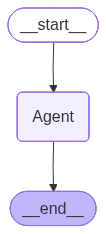

In [4]:
#Simple graph to test the model's responses
from langgraph.graph import START,StateGraph,MessagesState,END

from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display

builder = StateGraph(agent_state)

builder.add_node("Agent",conversation_agent)
#builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"Agent")
builder.add_edge("Agent",END)
#builder.add_conditional_edges("Agent",tools_condition)
#builder.add_edge("tools","Agent")
react_graph = builder.compile()


display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="Hi who are you and can you talk in telugu ?")]
messages = react_graph.invoke({"messages": messages,"language":"Telugu"})

ValueError: Unsupported language: Telugu. Supported languages are: ['English', 'Hindi', 'Kannada', 'Tamil', 'Telugu', 'unknown']

In [7]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi who are you and can you talk in telugu ?
================================== Ai Message ==================================

 హలో! నేను రిటైల్ సార్థి, భారతీయ కిరాణా స్టోర్ ఓనర్లకు సహాయపడే ఒక డిజిటల్ అసిస్టెంట్. నేను మీ వ్యాపారం, ఇన్వెంటరీ లేదా అమ్మకాల గురించి మీకు సమాచారం అందించగలను. అవును, నేను తెలుగులో మాట్లాడగలను. మీకు ఏ విషయంలో సహాయం కావాలో చెప్పండి!


In [8]:
print(messages['language'])

telugu
